# Diabetes Risk Prediction using BRFSS Health Indicators

A readable walkthrough of the reusable production pipeline. Run `python scripts/run_brfss_full_pipeline.py` before executing this notebook.

## tl;dr

The cells below load the saved, held-out results so the narrative always reflects the reproducible pipeline rather than notebook-only experimentation.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
TABLES = ROOT / 'reports' / 'brfss_final' / 'tables'
FIGURES = ROOT / 'reports' / 'brfss_final' / 'figures'
summary = json.loads((ROOT / 'reports' / 'brfss_final' / 'run_summary.json').read_text())
summary


{'dataset_shape': [253680, 22],
 'target_distribution': {'0': 213703, '1': 4631, '2': 35346},
 'original_feature_count': 21,
 'engineered_feature_count': 52,
 'selected_multiclass_model': 'XGBoost',
 'multiclass_cv_macro_f1_leader': {'model': 'ExtraTrees',
  'macro_f1': 0.4436134573423277},
 'multiclass_metrics': {'accuracy': 0.6492431409649952,
  'macro_f1': 0.4261622963342287,
  'weighted_f1': 0.7186602415865345,
  'balanced_accuracy': 0.5197527378003214,
  'macro_roc_auc_ovr': 0.7615236767185478,
  'macro_pr_auc_ovr': 0.4650004925249288},
 'selected_binary_model': 'XGBoost',
 'binary_cv_pr_auc_leader': {'model': 'XGBoost', 'pr_auc': 0.4183811563682684},
 'binary_metrics': {'threshold': 0.26,
  'roc_auc': 0.8286741499034429,
  'pr_auc': 0.4296731526347001,
  'recall': 0.5746215872117697,
  'precision': 0.3965247950019523,
  'f1': 0.4692427655518974,
  'balanced_accuracy': 0.7165250744129016,
  'brier_score': 0.0969608724117279},
 'xgboost_multiclass_cv_macro_f1': 0.423175665714866,
 

## Context & Methods

The main task predicts no diabetes, prediabetes and diabetes. A secondary binary task predicts diabetes. The test partition is held out before feature engineering, tuning, calibration or threshold selection.

### Key Assumptions

- Rows represent survey participants, but respondent IDs are unavailable.
- Exact response-profile duplicates are retained and disclosed.
- The model supports risk-screening analysis, not diagnosis.

## Data

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


,class,count,percentage,class_name
0,0,213703,0.842412,No diabetes
1,1,4631,0.018255,Prediabetes
2,2,35346,0.139333,Diabetes


,bmi_category,bmi_age_interaction,bmi_highbp_interaction,bmi_highchol_interaction,cardiometabolic_count,cardio_event_history,health_burden_score,socioeconomic_risk_count,age_bmi_interaction,age_cardiometabolic_interaction
0,3.0,360,40,40,4.0,0.0,7.1,1.0,360,36.0
1,2.0,175,0,0,0.0,0.0,3.0,1.0,175,0.0
2,2.0,252,28,28,3.0,0.0,8.0,0.0,252,27.0
3,2.0,297,27,0,1.0,0.0,2.0,1.0,297,11.0
4,1.0,264,24,24,2.0,0.0,2.1,0.0,264,22.0


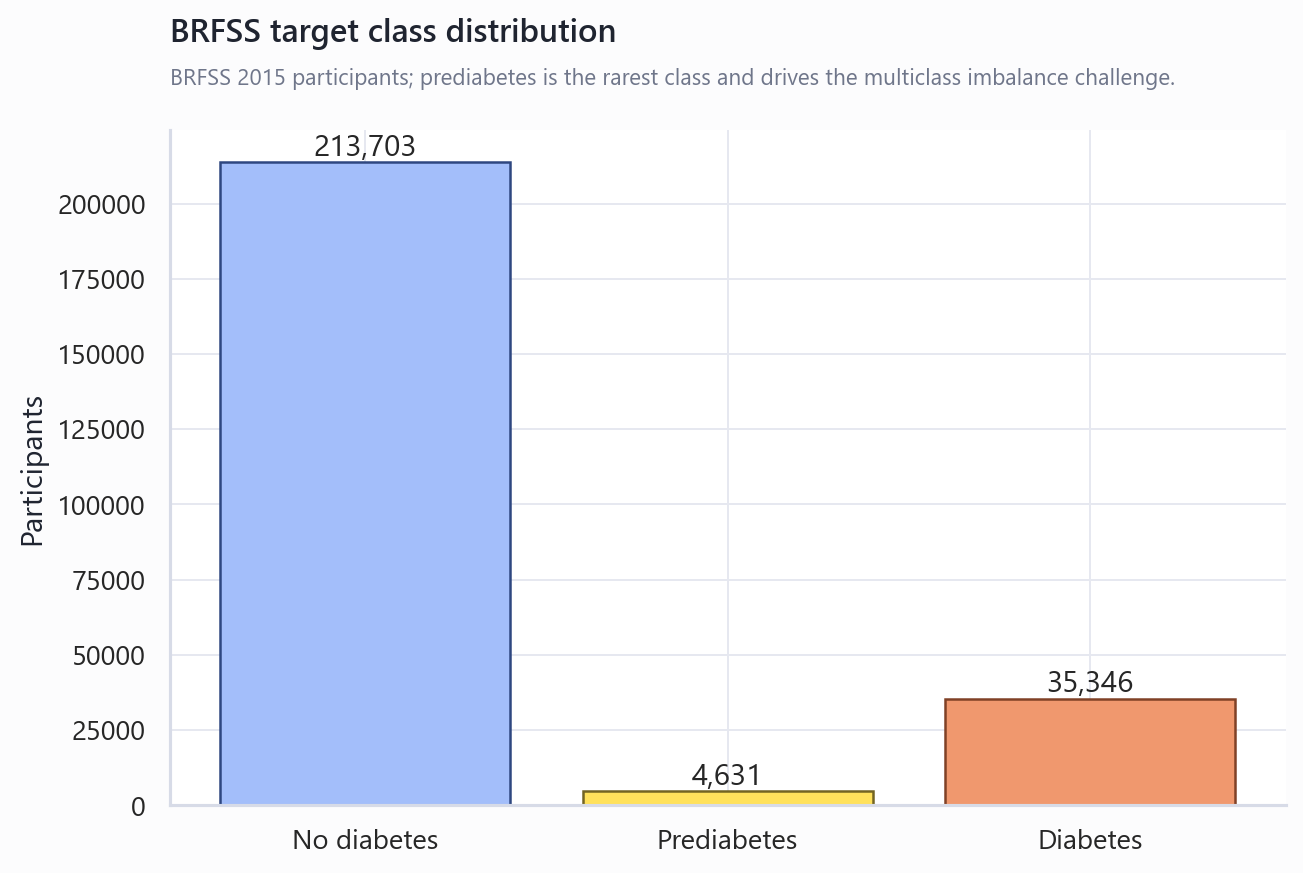

In [2]:
from brfss_diabetes.data_loading import load_brfss_data
from brfss_diabetes.feature_engineering import BRFSSFeatureEngineer

data = load_brfss_data()
display(data.head())
display(pd.read_csv(TABLES / 'class_distribution.csv'))
engineered = BRFSSFeatureEngineer().fit_transform(data.drop(columns='Diabetes_012').head(5))
display(engineered.filter(regex='bmi|cardio|health_burden|socioeconomic').head())
display(Image(filename=str(FIGURES / 'class_distribution.png')))


## Results

,model,cv_folds,macro_f1,macro_f1_std,balanced_accuracy,balanced_accuracy_std,class_0_recall,class_0_recall_std,class_1_recall,class_1_recall_std,class_2_recall,class_2_recall_std,macro_roc_auc_ovr,macro_roc_auc_ovr_std
0,ExtraTrees,3,0.4436,0.0032,0.4742,0.0052,0.8271,0.0074,0.0128,0.0083,0.5828,0.0165,0.7347,0.0046
1,Random Forest,3,0.4433,0.0039,0.4701,0.0033,0.8527,0.0058,0.0018,0.0032,0.5557,0.0102,0.7493,0.0029
2,XGBoost,3,0.4232,0.0066,0.5048,0.0069,0.6751,0.0137,0.1843,0.0078,0.6550,0.0148,0.7509,0.0029
3,Logistic Regression,3,0.4119,0.0049,0.4898,0.0114,0.6430,0.0139,0.2609,0.0297,0.5656,0.0295,0.7533,0.0086
4,DummyClassifier,3,0.3048,0.0000,0.3333,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000


,metric,value
0,accuracy,0.6492
1,macro_f1,0.4262
2,weighted_f1,0.7187
3,balanced_accuracy,0.5198
4,macro_roc_auc_ovr,0.7615
5,macro_pr_auc_ovr,0.4650


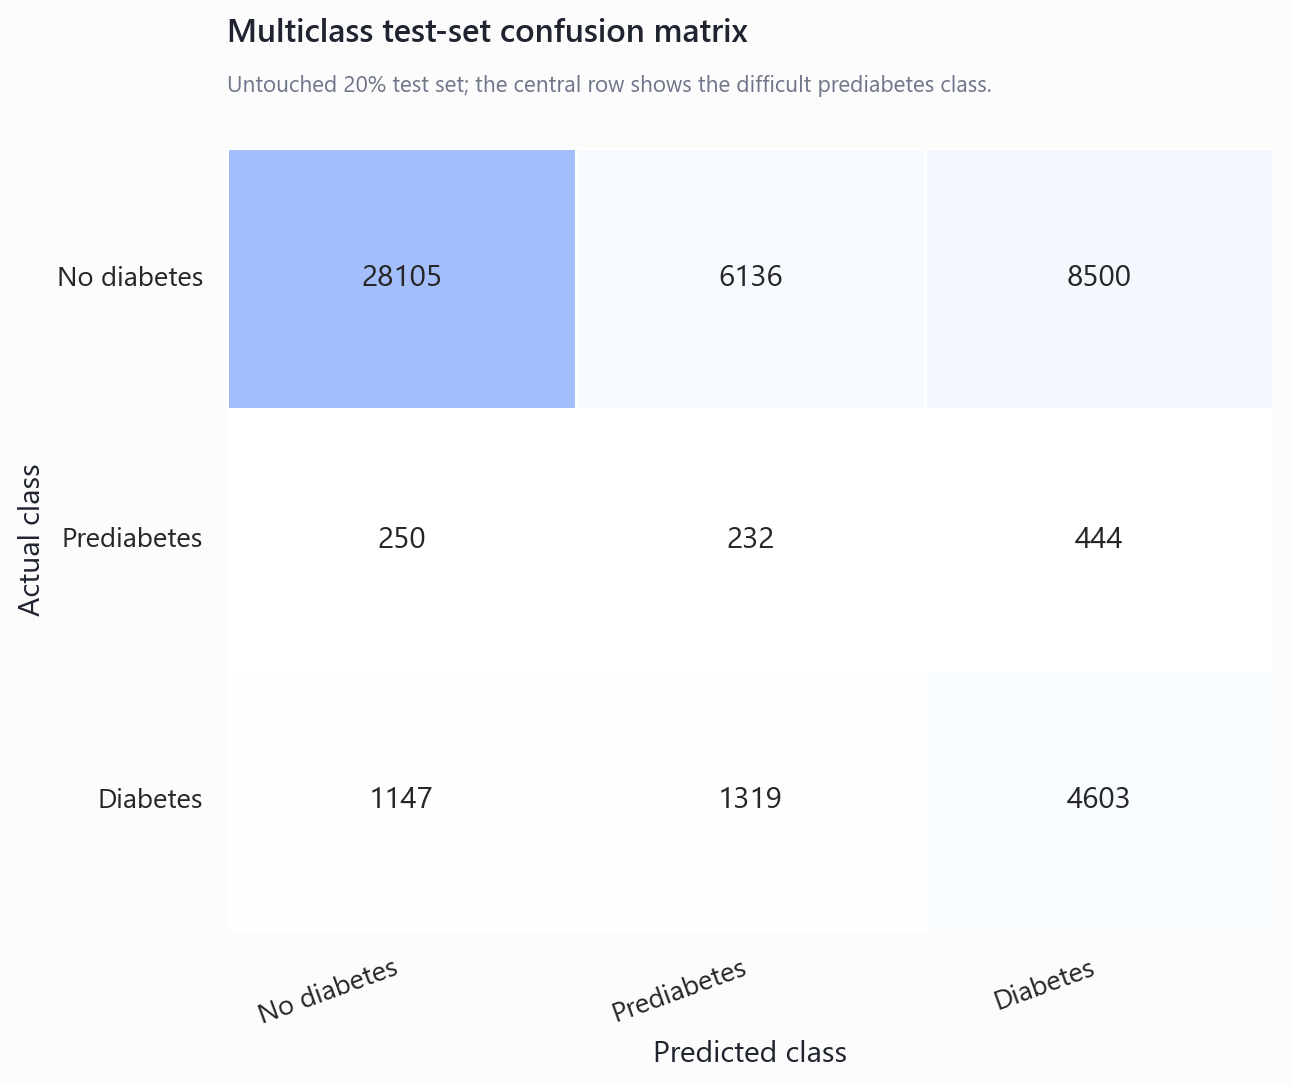

,model,cv_folds,pr_auc,pr_auc_std,roc_auc,roc_auc_std,f1,f1_std,balanced_accuracy,balanced_accuracy_std,recall,recall_std,precision,precision_std
0,XGBoost,3,0.4184,0.0102,0.8201,0.0051,0.4362,0.0051,0.7401,0.0052,0.7584,0.0095,0.3061,0.0036
1,Logistic Regression,3,0.4115,0.0126,0.8227,0.0054,0.4420,0.0018,0.7480,0.0020,0.7780,0.0076,0.3087,0.0021
2,Random Forest,3,0.3961,0.0051,0.8084,0.0049,0.4386,0.0052,0.6882,0.0015,0.5065,0.0032,0.3869,0.0101
3,ExtraTrees,3,0.3884,0.0048,0.8044,0.0028,0.4385,0.0070,0.6990,0.0047,0.5574,0.0084,0.3615,0.0072
4,DummyClassifier,3,0.1393,0.0001,0.5000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


,metric,value
0,threshold,0.2600
1,roc_auc,0.8287
2,pr_auc,0.4297
3,recall,0.5746
4,precision,0.3965
5,f1,0.4692
6,balanced_accuracy,0.7165
7,brier_score,0.0970


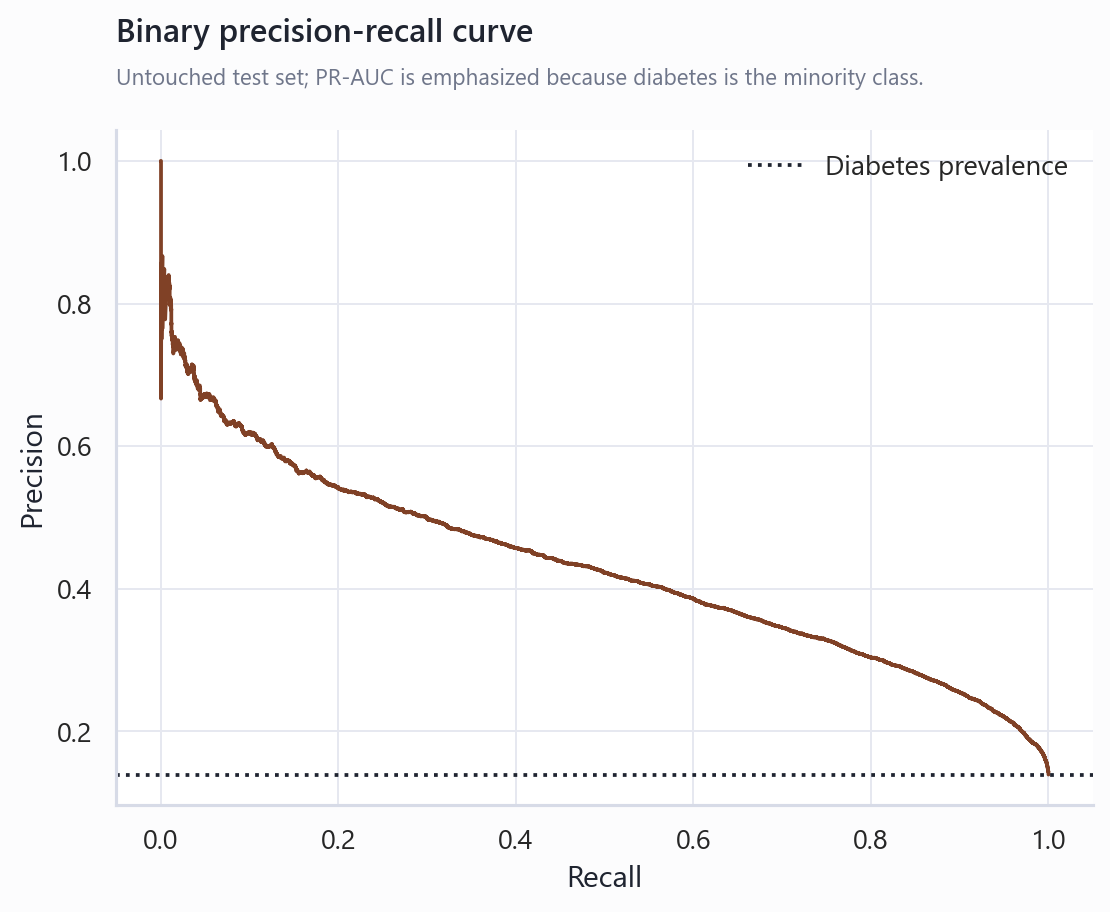

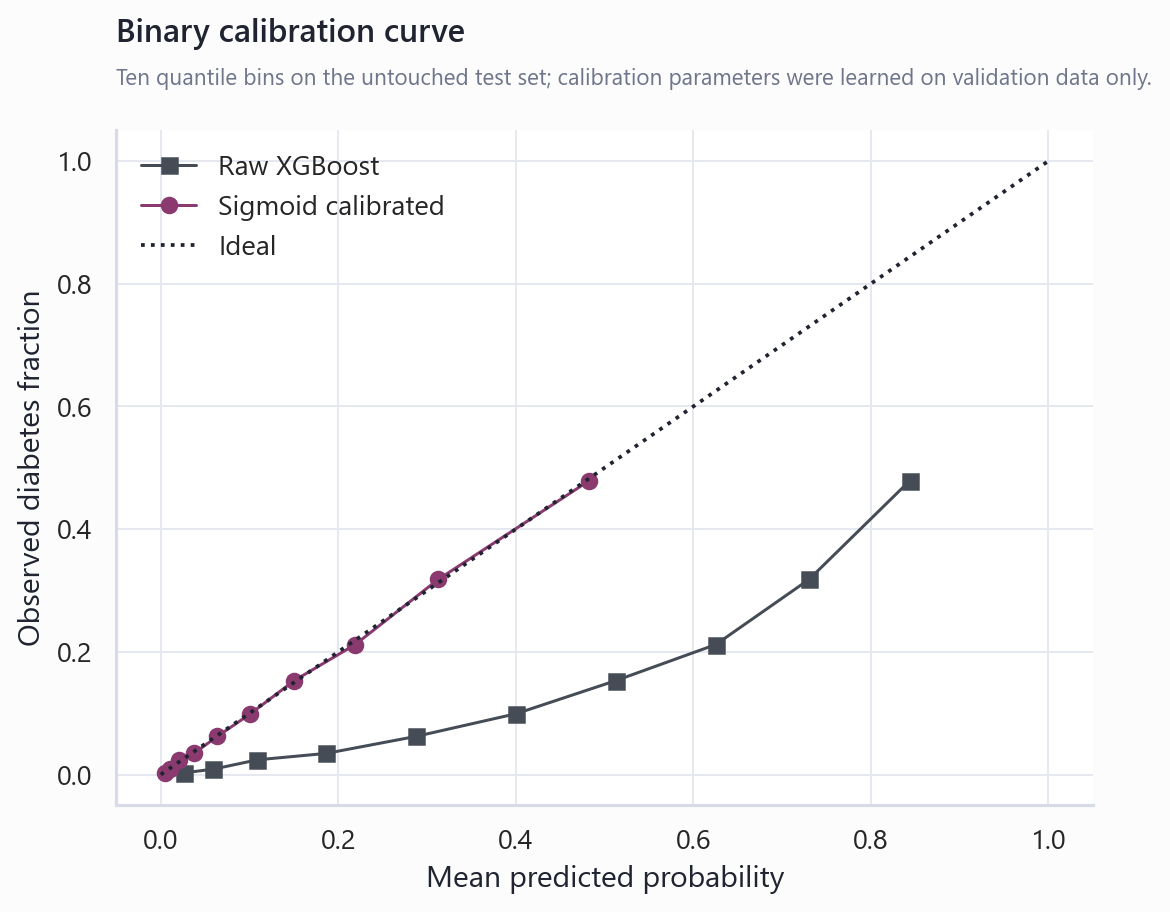

In [3]:
display(pd.read_csv(TABLES / 'model_comparison_multiclass.csv').round(4))
display(pd.read_csv(TABLES / 'final_test_metrics_multiclass.csv').round(4))
display(Image(filename=str(FIGURES / 'multiclass_confusion_matrix.png')))
display(pd.read_csv(TABLES / 'model_comparison_binary.csv').round(4))
display(pd.read_csv(TABLES / 'final_test_metrics_binary.csv').round(4))
display(Image(filename=str(FIGURES / 'binary_pr_curve.png')))
display(Image(filename=str(FIGURES / 'calibration_curve_binary.png')))


,removed_feature_family,remaining_feature_count,macro_f1,balanced_accuracy,macro_f1_drop,balanced_accuracy_drop
0,general health burden,42,0.4221,0.4831,0.0092,0.0053
1,lifestyle,44,0.4304,0.4904,0.0009,-0.0021
2,engineered interactions,44,0.4305,0.4935,0.0008,-0.0052
3,BMI/obesity,48,0.4308,0.4885,0.0005,-0.0002
4,none (baseline),52,0.4313,0.4883,0.0000,0.0000
5,healthcare access,46,0.4327,0.4905,-0.0015,-0.0022
6,demographics,48,0.4346,0.4956,-0.0033,-0.0073
7,socioeconomic status,47,0.4362,0.4982,-0.0049,-0.0098
8,cardiometabolic history,45,0.4364,0.4967,-0.0051,-0.0084


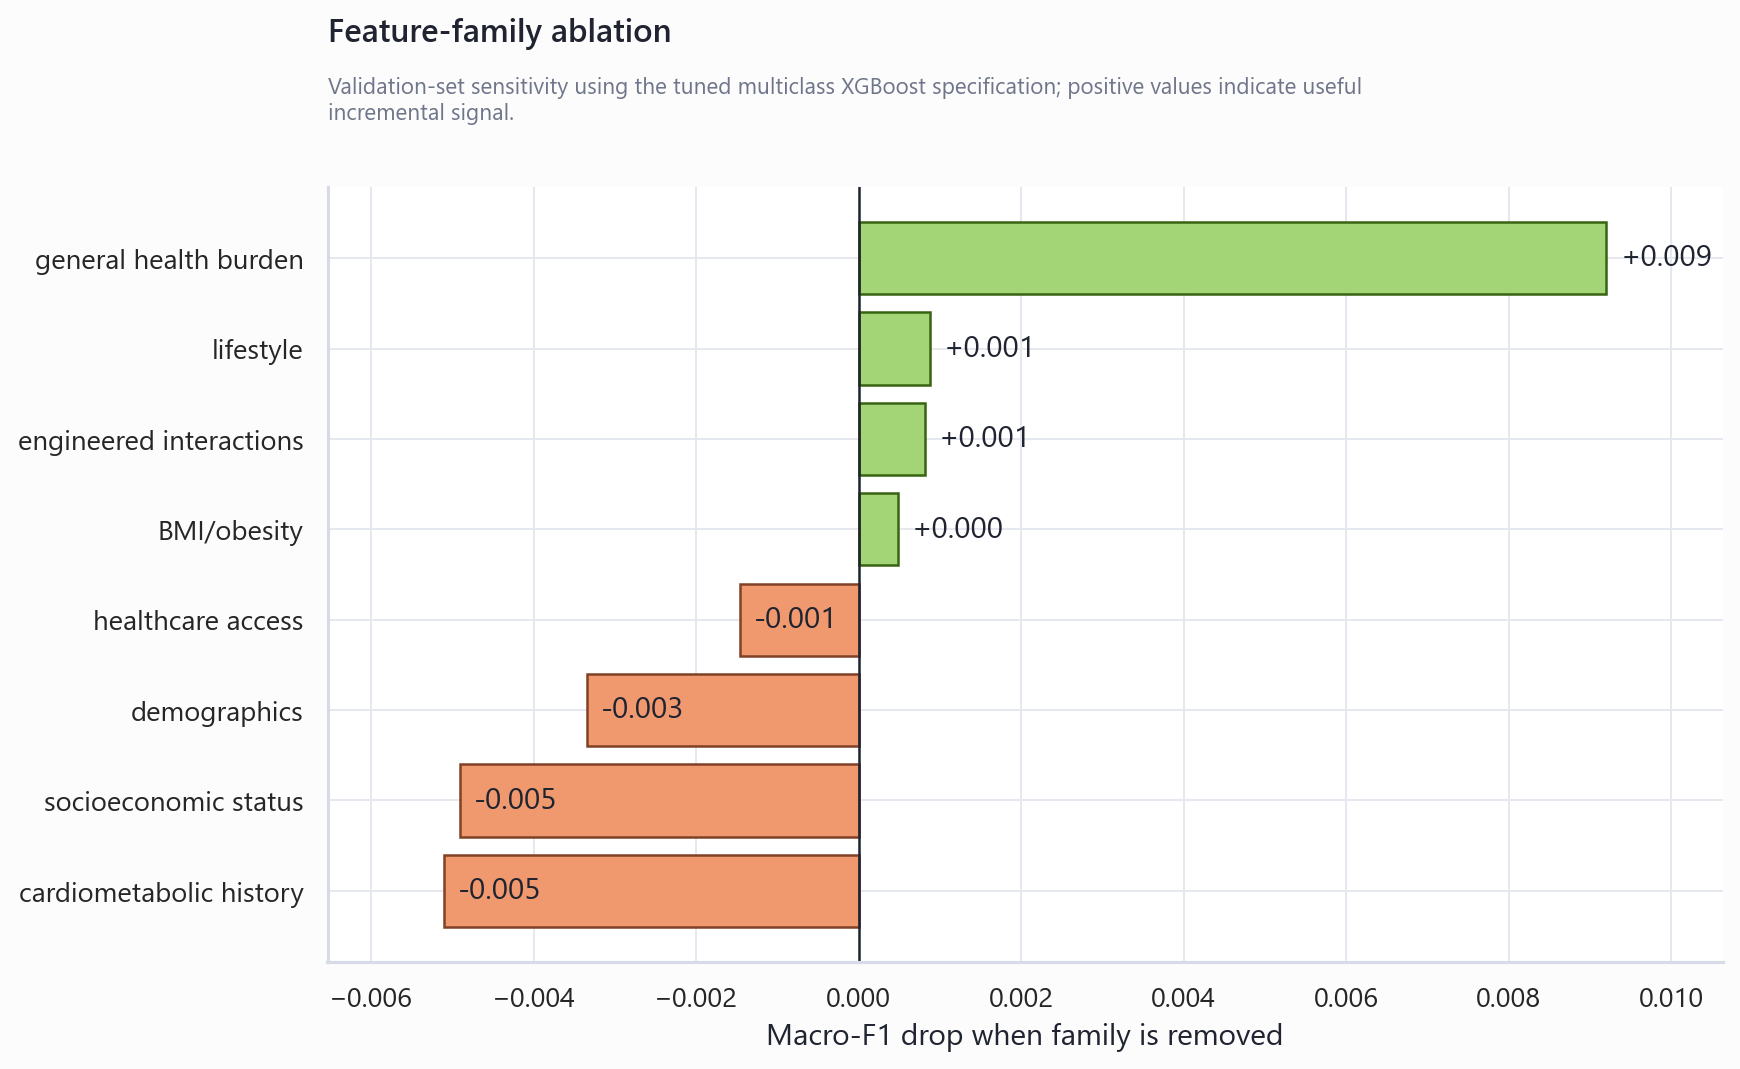

,error_type,count,percentage_of_test_set,mean_BMI,mean_Age,mean_GenHlth,mean_HighBP,mean_HighChol,mean_Income
0,diabetes_false_negative,3007,0.0593,28.4905,9.0166,2.7034,0.5304,0.5028,5.9056
1,diabetes_false_positive,6182,0.1218,32.9502,9.7422,3.5542,0.8845,0.7454,4.9400
2,prediabetes_to_no_diabetes,250,0.0049,27.2760,7.6400,2.2800,0.2680,0.3560,6.0680
3,prediabetes_to_diabetes,444,0.0088,33.0991,9.6779,3.4392,0.8446,0.7185,4.9752


,dimension,group,n,macro_f1,balanced_accuracy,class_0_recall,class_1_recall,class_2_recall
0,age_group,35-54 approx.,18711,0.4375,0.5309,0.7563,0.2674,0.5690
1,age_group,55-69 approx.,17766,0.3965,0.4855,0.5037,0.2335,0.7194
2,age_group,70+ approx.,6608,0.3232,0.4347,0.3404,0.3098,0.6539
3,age_group,18-34 approx.,7651,0.4355,0.4494,0.9470,0.1000,0.3013
4,sex,Male,22527,0.4184,0.5152,0.6289,0.2346,0.6822
5,sex,Female,28209,0.4323,0.5218,0.6799,0.2630,0.6224
6,income_group,Higher,26762,0.4299,0.5083,0.7774,0.2114,0.5361
7,income_group,Middle,16547,0.4001,0.5045,0.5441,0.2806,0.6889
8,income_group,Lower,7427,0.3838,0.4766,0.4107,0.2639,0.7554
9,education_group,College graduate,21505,0.4302,0.5131,0.7670,0.2323,0.5399


In [4]:
display(pd.read_csv(TABLES / 'feature_family_ablation.csv').round(4))
display(Image(filename=str(FIGURES / 'feature_family_ablation.png')))
display(pd.read_csv(TABLES / 'error_analysis.csv').round(4))
display(pd.read_csv(TABLES / 'subgroup_performance.csv').round(4))


## Takeaways

The official conclusions, exact metrics, limitations and CV positioning are rendered from the saved outputs below.

In [5]:
display(Markdown((ROOT / 'reports' / 'brfss_final' / 'FINAL_REPORT.md').read_text(encoding='utf-8')))


# Diabetes Risk Prediction using BRFSS Health Indicators

## Technical summary

The official project uses BRFSS 2015 survey indicators for two related screening tasks: three-class diabetes status and binary diabetes risk. The final multiclass XGBoost achieved **macro-F1 0.426**, **balanced accuracy 0.520**, prediabetes recall **0.251**, and diabetes recall **0.651** on the untouched test set. The calibrated binary model achieved **ROC-AUC 0.829**, **PR-AUC 0.430**, and recall **0.575** at threshold **0.26**.

**Model-selection conclusion:** ExtraTrees led multiclass CV macro-F1 (0.444 versus 0.423 for XGBoost). XGBoost remained the selected final multiclass model because its weighted operating point improved prediabetes recall (0.184 versus 0.013) and balanced accuracy (0.505 versus 0.474). XGBoost led the primary binary CV metric, PR-AUC (0.418). The model is suitable as a portfolio demonstration of reproducible risk-screening ML, not as a medical diagnostic system.

## The rare prediabetes class defines the multiclass difficulty

The dataset contains **253,680 rows**, **21 original predictors**, and no missing values. Prediabetes represents only **1.83%** of rows. Exact duplicate response rows were retained because the public extract has no respondent identifier; identical response profiles cannot be proven to be duplicate people.

| class | count | percentage | class_name |
| --- | --- | --- | --- |
| 0 | 213703 | 0.8424 | No diabetes |
| 1 | 4631 | 0.0183 | Prediabetes |
| 2 | 35346 | 0.1393 | Diabetes |

![BRFSS class distribution](figures/class_distribution.png)

This imbalance means raw accuracy would reward predicting the majority class. Macro-F1, balanced accuracy and class-wise recall therefore governed model selection.

## Multiclass and binary tasks answer different screening questions

The official task predicts `Diabetes_012`: 0 for no diabetes, 1 for prediabetes and 2 for diabetes. The secondary task predicts diabetes versus no diabetes/prediabetes. The multiclass task preserves the clinically meaningful intermediate group; the binary task provides a more separable benchmark and supports probability calibration and operating-threshold analysis.

## Data validation found no missingness but identified profile duplication

All expected columns were available and all coded ranges passed validation. There were 23,899 exact duplicate rows. Because no respondent key is present, rows were retained and split using reproducible stratification. This can make performance optimistic when identical profiles appear across partitions and is documented as a limitation.

## Domain features expanded the model from 21 to 52 predictors

Feature engineering retained all original variables and added BMI categories, cardiometabolic burden, lifestyle risk, healthcare access, general-health burden, socioeconomic risk and interactions. Every transformation is deterministic and occurs inside the fitted pipeline.

The highest-impact families in validation ablation were: **general health burden, lifestyle, engineered interactions**.

![Feature-family ablation](figures/feature_family_ablation.png)

Positive drops show that removing the family reduced macro-F1. Small or negative drops indicate redundancy or weak incremental signal, not clinical irrelevance.

## Leakage-safe preprocessing and imbalance handling

The untouched test set was split before feature engineering, imputation, scaling, tuning, calibration or threshold selection. Linear models used median imputation, scaling and one-hot encoding for engineered ordinal categories. Tree models retained ordinal codes with median imputation. Multiclass XGBoost used training-fold balanced sample weights; synthetic oversampling was not selected because the coded survey feature space and calibration objective made class weighting the lower-risk default.

## XGBoost was tuned against strong baselines

| model | cv_folds | macro_f1 | macro_f1_std | balanced_accuracy | balanced_accuracy_std | class_0_recall | class_0_recall_std | class_1_recall | class_1_recall_std | class_2_recall | class_2_recall_std | macro_roc_auc_ovr | macro_roc_auc_ovr_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ExtraTrees | 3 | 0.4436 | 0.0032 | 0.4742 | 0.0052 | 0.8271 | 0.0074 | 0.0128 | 0.0083 | 0.5828 | 0.0165 | 0.7347 | 0.0046 |
| Random Forest | 3 | 0.4433 | 0.0039 | 0.4701 | 0.0033 | 0.8527 | 0.0058 | 0.0018 | 0.0032 | 0.5557 | 0.0102 | 0.7493 | 0.0029 |
| XGBoost | 3 | 0.4232 | 0.0066 | 0.5048 | 0.0069 | 0.6751 | 0.0137 | 0.1843 | 0.0078 | 0.6550 | 0.0148 | 0.7509 | 0.0029 |
| Logistic Regression | 3 | 0.4119 | 0.0049 | 0.4898 | 0.0114 | 0.6430 | 0.0139 | 0.2609 | 0.0297 | 0.5656 | 0.0295 | 0.7533 | 0.0086 |
| DummyClassifier | 3 | 0.3048 | 0.0000 | 0.3333 | 0.0000 | 1.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.0000 |

![Multiclass model comparison](figures/model_comparison_multiclass.png)

| model | cv_folds | pr_auc | pr_auc_std | roc_auc | roc_auc_std | f1 | f1_std | balanced_accuracy | balanced_accuracy_std | recall | recall_std | precision | precision_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| XGBoost | 3 | 0.4184 | 0.0102 | 0.8201 | 0.0051 | 0.4362 | 0.0051 | 0.7401 | 0.0052 | 0.7584 | 0.0095 | 0.3061 | 0.0036 |
| Logistic Regression | 3 | 0.4115 | 0.0126 | 0.8227 | 0.0054 | 0.4420 | 0.0018 | 0.7480 | 0.0020 | 0.7780 | 0.0076 | 0.3087 | 0.0021 |
| Random Forest | 3 | 0.3961 | 0.0051 | 0.8084 | 0.0049 | 0.4386 | 0.0052 | 0.6882 | 0.0015 | 0.5065 | 0.0032 | 0.3869 | 0.0101 |
| ExtraTrees | 3 | 0.3884 | 0.0048 | 0.8044 | 0.0028 | 0.4385 | 0.0070 | 0.6990 | 0.0047 | 0.5574 | 0.0084 | 0.3615 | 0.0072 |
| DummyClassifier | 3 | 0.1393 | 0.0001 | 0.5000 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |

![Binary model comparison](figures/model_comparison_binary.png)

Logistic regression regularization, Random Forest structure and XGBoost parameters were tuned using training-only cross-validation. XGBoost tuning covered estimators, depth, learning rate, subsampling, column sampling, child weight, gamma and L1/L2 regularization. Selected multiclass XGBoost parameters: `{'colsample_bytree': 0.7713532627589614, 'gamma': 0.4563633644393066, 'learning_rate': 0.061738558891618764, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 228, 'reg_alpha': 0.012563152773938664, 'reg_lambda': 1.5151324184839015, 'subsample': 0.7330663856998123}`. Selected binary XGBoost parameters: `{'colsample_bytree': 0.9926515452756086, 'gamma': 0.34915701064545634, 'learning_rate': 0.029223394319260826, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 287, 'reg_alpha': 0.011400863701127324, 'reg_lambda': 2.584093506411774, 'subsample': 0.7330061155615993, 'scale_pos_weight': 6.176998974431517}`.

## Final multiclass errors concentrate around prediabetes

| metric | value |
| --- | --- |
| accuracy | 0.6492 |
| macro_f1 | 0.4262 |
| weighted_f1 | 0.7187 |
| balanced_accuracy | 0.5198 |
| macro_roc_auc_ovr | 0.7615 |
| macro_pr_auc_ovr | 0.4650 |

| class | precision | recall | f1-score | support |
| --- | --- | --- | --- | --- |
| No diabetes | 0.9526 | 0.6576 | 0.7781 | 42741.0000 |
| Prediabetes | 0.0302 | 0.2505 | 0.0539 | 926.0000 |
| Diabetes | 0.3398 | 0.6512 | 0.4465 | 7069.0000 |
| accuracy | 0.6492 | 0.6492 | 0.6492 | 0.6492 |
| macro avg | 0.4409 | 0.5198 | 0.4262 | 50736.0000 |
| weighted avg | 0.8504 | 0.6492 | 0.7187 | 50736.0000 |

![Multiclass confusion matrix](figures/multiclass_confusion_matrix.png)

Prediabetes has weaker separability than diabetes because it is rare and BRFSS indicators are survey/self-reported rather than glycemic biomarkers. Confusions with both no diabetes and diabetes are therefore reported directly rather than hidden by aggregate accuracy.

## The binary task supports calibrated risk screening

| metric | value |
| --- | --- |
| threshold | 0.2600 |
| roc_auc | 0.8287 |
| pr_auc | 0.4297 |
| recall | 0.5746 |
| precision | 0.3965 |
| f1 | 0.4692 |
| balanced_accuracy | 0.7165 |
| brier_score | 0.0970 |

| class | precision | recall | f1-score | support |
| --- | --- | --- | --- | --- |
| No diabetes | 0.9257 | 0.8584 | 0.8908 | 43667.0000 |
| Diabetes | 0.3965 | 0.5746 | 0.4692 | 7069.0000 |
| accuracy | 0.8189 | 0.8189 | 0.8189 | 0.8189 |
| macro avg | 0.6611 | 0.7165 | 0.6800 | 50736.0000 |
| weighted avg | 0.8520 | 0.8189 | 0.8321 | 50736.0000 |

![Binary precision-recall curve](figures/binary_pr_curve.png)

![Binary calibration curve](figures/calibration_curve_binary.png)

The sigmoid calibrator and operating threshold were learned from validation probabilities only. The test set was used once for the final metric readout.

## Threshold choice changes the screening operating point

| threshold | precision | recall | f1 | balanced_accuracy | predicted_positive_rate | meets_minimum_precision | selection |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.1100 | 0.2782 | 0.8522 | 0.4194 | 0.7471 | 0.4269 | False | \|high_recall |
| 0.1500 | 0.3121 | 0.7864 | 0.4469 | 0.7529 | 0.3511 | False | \|balanced_precision_recall |
| 0.2000 | 0.3530 | 0.6912 | 0.4674 | 0.7431 | 0.2728 | True | \|minimum_precision |
| 0.2600 | 0.4015 | 0.5750 | 0.4729 | 0.7181 | 0.1995 | True | max_f1 |

![Threshold trade-off](figures/threshold_precision_recall_tradeoff.png)

The saved binary report uses the validation-selected max-F1 threshold. Other rows support high-recall or minimum-precision operating points without pretending one threshold is universally correct.

The multiclass high-risk sensitivity analysis defines high risk as class 1 or 2:

| threshold | high_risk_precision | high_risk_recall | f1 | balanced_accuracy | predicted_positive_rate | meets_minimum_precision | selection |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.2100 | 0.2014 | 0.9804 | 0.3342 | 0.6267 | 0.7669 | True | \|minimum_precision |
| 0.5900 | 0.2973 | 0.8537 | 0.4411 | 0.7382 | 0.4524 | True | \|high_recall |
| 0.6600 | 0.3287 | 0.7909 | 0.4644 | 0.7444 | 0.3791 | True | \|balanced_precision_recall |
| 0.7800 | 0.4164 | 0.5981 | 0.4910 | 0.7206 | 0.2263 | True | max_f1 |
| 0.8676 | 0.5110 | 0.3244 |  |  | 0.1000 | True | top_10_percent |
| 0.7997 | 0.4329 | 0.5495 |  |  | 0.2000 | True | top_20_percent |
| 0.7253 | 0.3672 | 0.6992 |  |  | 0.3000 | True | top_30_percent |
| 0.6402 | 0.3190 | 0.8099 |  |  | 0.4000 | True | top_40_percent |
| 0.5419 | 0.2800 | 0.8885 |  |  | 0.5000 | True | top_50_percent |

## Multiple interpretation methods agree on the main signal families

![XGBoost feature importance](figures/top_feature_importance_xgboost.png)

![Permutation importance](figures/permutation_importance_top20.png)

Built-in importance, held-out permutation importance and family ablation were all used. These methods describe predictive contribution; none establishes causal or clinical effect.

Top built-in features:

| feature | importance | feature_family |
| --- | --- | --- |
| age_cardiometabolic_interaction | 0.0794 | engineered interactions |
| cardiometabolic_count | 0.0780 | cardiometabolic history |
| GenHlth | 0.0510 | general health burden |
| poor_general_health_flag | 0.0374 | general health burden |
| cholcheck_with_highchol_flag | 0.0261 | healthcare access |
| health_burden_score | 0.0260 | general health burden |
| bmi_highbp_interaction | 0.0238 | engineered interactions |
| HighBP | 0.0232 | cardiometabolic history |
| bmi_age_interaction | 0.0231 | engineered interactions |
| HvyAlcoholConsump | 0.0197 | lifestyle |
| CholCheck | 0.0187 | healthcare access |
| physical_inactivity_flag | 0.0176 | lifestyle |
| age_bmi_interaction | 0.0173 | engineered interactions |
| bmi_highchol_interaction | 0.0169 | engineered interactions |
| age_band | 0.0166 | demographics |

Top permutation features:

| feature | importance_mean | importance_std | feature_family |
| --- | --- | --- | --- |
| bmi_highbp_interaction | 0.0051 | 0.0009 | engineered interactions |
| Sex | 0.0033 | 0.0009 | demographics |
| HvyAlcoholConsump | 0.0032 | 0.0013 | lifestyle |
| income_education_interaction | 0.0022 | 0.0014 | engineered interactions |
| Smoker | 0.0014 | 0.0007 | lifestyle |
| HighBP | 0.0014 | 0.0004 | cardiometabolic history |
| bmi_age_interaction | 0.0014 | 0.0015 | engineered interactions |
| GenHlth | 0.0012 | 0.0003 | general health burden |
| healthcare_access_barrier | 0.0012 | 0.0003 | healthcare access |
| HeartDiseaseorAttack | 0.0012 | 0.0004 | cardiometabolic history |
| PhysActivity | 0.0011 | 0.0004 | lifestyle |
| bmi_highchol_interaction | 0.0011 | 0.0008 | engineered interactions |
| bp_cholesterol_combo | 0.0009 | 0.0001 | cardiometabolic history |
| cardiometabolic_count | 0.0007 | 0.0008 | cardiometabolic history |
| CholCheck | 0.0006 | 0.0004 | healthcare access |

## Error and subgroup diagnostics expose where the model is weakest

| error_type | count | percentage_of_test_set | mean_BMI | mean_Age | mean_GenHlth | mean_HighBP | mean_HighChol | mean_Income |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| diabetes_false_negative | 3007 | 0.0593 | 28.4905 | 9.0166 | 2.7034 | 0.5304 | 0.5028 | 5.9056 |
| diabetes_false_positive | 6182 | 0.1218 | 32.9502 | 9.7422 | 3.5542 | 0.8845 | 0.7454 | 4.9400 |
| prediabetes_to_no_diabetes | 250 | 0.0049 | 27.2760 | 7.6400 | 2.2800 | 0.2680 | 0.3560 | 6.0680 |
| prediabetes_to_diabetes | 444 | 0.0088 | 33.0991 | 9.6779 | 3.4392 | 0.8446 | 0.7185 | 4.9752 |

| dimension | group | n | macro_f1 | balanced_accuracy | class_0_recall | class_1_recall | class_2_recall |
| --- | --- | --- | --- | --- | --- | --- | --- |
| age_group | 35-54 approx. | 18711 | 0.4375 | 0.5309 | 0.7563 | 0.2674 | 0.5690 |
| age_group | 55-69 approx. | 17766 | 0.3965 | 0.4855 | 0.5037 | 0.2335 | 0.7194 |
| age_group | 70+ approx. | 6608 | 0.3232 | 0.4347 | 0.3404 | 0.3098 | 0.6539 |
| age_group | 18-34 approx. | 7651 | 0.4355 | 0.4494 | 0.9470 | 0.1000 | 0.3013 |
| sex | Male | 22527 | 0.4184 | 0.5152 | 0.6289 | 0.2346 | 0.6822 |
| sex | Female | 28209 | 0.4323 | 0.5218 | 0.6799 | 0.2630 | 0.6224 |
| income_group | Higher | 26762 | 0.4299 | 0.5083 | 0.7774 | 0.2114 | 0.5361 |
| income_group | Middle | 16547 | 0.4001 | 0.5045 | 0.5441 | 0.2806 | 0.6889 |
| income_group | Lower | 7427 | 0.3838 | 0.4766 | 0.4107 | 0.2639 | 0.7554 |
| education_group | College graduate | 21505 | 0.4302 | 0.5131 | 0.7670 | 0.2323 | 0.5399 |
| education_group | Some college | 26509 | 0.4128 | 0.5095 | 0.5862 | 0.2519 | 0.6904 |
| education_group | High school or lower | 2722 | 0.3740 | 0.4666 | 0.3694 | 0.2952 | 0.7351 |

Subgroup diagnostics are descriptive checks by age, sex, income and education. They are not a fairness certification because BRFSS coding, sample composition and outcome quality can differ across groups.

## Limitations and robustness checks

- BRFSS is survey and self-reported data; labels and predictors may contain recall or reporting error.
- The model is a risk-screening exercise, not a diagnostic medical system.
- Prediabetes is difficult because of severe class imbalance and weak survey-feature separability.
- Exact profile duplicates were retained because respondent identifiers are absent; this may produce optimistic random-split estimates.
- The single 2015 extract provides internal holdout validation, not temporal or external validation.
- Feature importance is associative and should not be interpreted as clinical causality.
- Calibration and threshold choices may shift under a different population prevalence.

## Recommended next steps

Use the BRFSS project as the official CV project. Position the contribution around leakage-safe pipeline design, domain features, imbalance-aware evaluation, XGBoost tuning, calibration, threshold selection and honest prediabetes limitations. Keep the NHANES work as a rejected feasibility extension demonstrating evidence-based project selection.

## Further questions

- Does performance remain stable under a grouped split that keeps identical feature profiles together?
- How does the model generalize to a later BRFSS cycle?
- Can cost-sensitive objectives improve prediabetes recall without unacceptable false positives?
